## Setup

In [2]:
# from agentic.tools.rag_tools import search_knowledge_base
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
from agentic.tools.rag_tools import search_knowledge_base
from agentic.tools.persistence import persist_ticket
from agentic.agents.account_resolver import account_resolver, resolve_account_ticket
from agentic.agents.general_resolver import general_resolver, resolve_general_ticket
from agentic.agents.support_agents import classify_ticket, score_resolution, escalation_agent

search_knowledge_base("Who are you?")

[]

In [65]:
from dotenv import load_dotenv
from utils import chat_interface
from typing import Annotated, Literal, List, Dict, Optional
import operator
import uuid
import json
from langchain_core.documents import Document
from langgraph.prebuilt import InjectedState
from langgraph.prebuilt.chat_agent_executor import AgentStateWithStructuredResponse
from pydantic import BaseModel
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_core.prompts import ChatPromptTemplate
import nest_asyncio
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

In [66]:
__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')

# Verify that it worked
import sqlite3
print("Patched SQLite version:", sqlite3.sqlite_version)

Patched SQLite version: 3.51.1


In [11]:
nest_asyncio.apply()

In [12]:
load_dotenv()

True

## Run

In [13]:
# TODO: Develop your agents under `agentic/agents`
# TODO: Develop your tools under `agentic/tools`
# TODO: Modify `agentic/workflow` in order to orchestrate your agents

In [14]:
# IDEALLY YOUR ONLY IMPORT HERE IS:
# from agentic.workflow import orchestrator

from agentic.workflow import orchestrator

CONFIDENCE_THRESHOLD = 0.7

voc-46826042716695048170586a92ba652104b0.09031598


In [15]:
# chat_interface(orchestrator, "1")

In [16]:
# list(orchestrator.get_state_history(
#     config = {
#         "configurable": {
#             "thread_id": "1",
#         }
#     }
# ))[0].values["messages"]

In [52]:
class State(MessagesState):
    user_id: str
    ticket_status: str
    ticket_data: dict
    thread_id: str
    resolution_confidence_score: float
    retrieved_docs: List[str]
    account_evidence: Optional[dict[str, list[str]]]
    escalation_reason: str
    route: str
    routing_reason: str
    decision_log: Annotated[List[Dict], operator.add]
    user_history: List[Document]
    response: Annotated[List[str|Dict], operator.add]

In [18]:
class RouteDecision(BaseModel):
    """Used by Classifier once the ticket is classified"""
    route: Literal["account", "general"]
    routing_reason: str
    confidence: float

class ResolverOutput(BaseModel):
    """Used by Resolver agents"""
    answer: str
    sources_used: List[str]  
    grounded: bool

class AccountResolverState(AgentStateWithStructuredResponse):
    user_id: str


class ScoreOutput(BaseModel):
    confidence: float
    scoring_reason: str


class EscalationOutput(BaseModel):
    user_message: str       
    escalation_reason: str 

In [19]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.0,
    base_url=os.getenv("BASE_URL"),
    api_key=os.getenv("OPENAI_API_KEY")
)

In [91]:
from utils import reset_db, get_session, model_to_dict
from sqlalchemy import create_engine
from data.models import cultpass
from data.models.cultpass import User as CultpassUser
from data.models.udahub import Knowledge

cultpass_db = "data/external/cultpass.db"
engine = create_engine(f"sqlite:///{cultpass_db}", echo=False)

with get_session(engine) as session:
    users = session.query(cultpass.User).all()
    for user in users:
        print(user)

    user = session.get(CultpassUser, 'a4ab87')
    print(user)

<User(user_id='a4ab87', email='alice.kingsley@wonderland.com', is_blocked=True)>
<User(user_id='f556c0', email='bob.stone@granite.com', is_blocked=False)>
<User(user_id='88382b', email='cathy.bloom@florals.org', is_blocked=False)>
<User(user_id='888fb2', email='david.noir@shadowmail.com', is_blocked=True)>
<User(user_id='f1f10d', email='eva.green@ecosoul.net', is_blocked=False)>
<User(user_id='e6376d', email='frank.ocean@seawaves.io', is_blocked=False)>
<User(user_id='a4ab87', email='alice.kingsley@wonderland.com', is_blocked=True)>


In [73]:
def get_account_profile(user_id: Annotated[str, InjectedState("user_id")]) -> dict:
    """Returns subscription tier, status, monthly quota, and whether the account is blocked."""
    with get_session(engine) as session:
        user = session.get(CultpassUser, user_id)
        if user is None:
            return {"error": "User not found"}
        subscription = user.subscription
        if subscription is None:
            return {"message": "User has no subscription"}
        
        return {
            "tier": subscription.tier,
            "status": subscription.status,
            "monthly_quota": subscription.monthly_quota,
            "started_at": subscription.started_at,
            "ended_at": subscription.ended_at,
            "is_blocked": user.is_blocked,
        }

def get_reservation_history(user_id: Annotated[str, InjectedState("user_id")]) -> list[dict]:
    """Returns the user's reservations with experience details and status."""
    experiences = []
    with get_session(engine) as session:
        user = session.get(CultpassUser, user_id)
        if user is None:
            return [{"error": "User not found"}]
        reservations = user.reservations
        if len(reservations) == 0:
            return []
        else:
            for reservation in reservations:
                experience = reservation.experience
                experiences.append(
                    {
                        "title": experience.title,
                        "location": experience.location,
                        "when": experience.when,
                        "slots_available": experience.slots_available,
                        "is_premium": experience.is_premium,
                        "status": reservation.status,

                    }
                )
    
    return experiences

def search_knowledge_base(query: str) -> list[dict]:
    """Queries the Knowledge Base, returning relevant article, content information"""
    embeddings_fn = OpenAIEmbeddings(
        model="text-embedding-3-large",
        base_url = os.getenv("BASE_URL"),
        api_key=os.getenv("OPENAI_API_KEY"),
    )

    vector_store = Chroma(
        collection_name="udahubassistant",
        embedding_function=embeddings_fn,
        persist_directory="./cultpass_knowledge_base"
    )

    documents = vector_store.similarity_search(query, k=5)
    result = []
    if len(documents) > 0:
        for doc in documents:
            result.append({
                "title": doc.metadata["title"], 
                "content": doc.page_content, 
                "tags": doc.metadata.get("tags"),
                "id": doc.id
            })

    return result
 


In [24]:
# search_knowledge_base("how do I reserve a spot for an experience")

In [25]:
from data.models.udahub import Knowledge


def build_knowledge_index():
    """Builds the Knowledge base"""
    udahub_db = "data/core/udahub.db"
    engine = create_engine(f"sqlite:///{udahub_db}", echo=False)
    embeddings_fn = OpenAIEmbeddings(
        model="text-embedding-3-large",
        base_url = os.getenv("BASE_URL"),
        api_key=os.getenv("OPENAI_API_KEY"),
    )

    vector_store = Chroma(
        collection_name="udahubassistant",
        embedding_function=embeddings_fn,
        persist_directory="./cultpass_knowledge_base"
    )

    documents = []
    with get_session(engine) as session:
        knowledge = session.query(Knowledge).all()
        if len(knowledge) == 0:
            return [{"error": "No information found"}]
        
        for article in knowledge:
            doc = Document(
                page_content=article.content,       
                metadata={"title": article.title, "tags": article.tags},   
                id=article.article_id                    
            )
            documents.append(doc)
    
    vector_store.add_documents(documents=documents)

    return "Successfully saved to Knowledge base!"

# build_knowledge_index()

In [26]:
def classify_ticket(state: State) -> State:
    """Classify the topic/category of a ticket inquiry."""
    ticket_query = state["ticket_data"]["content"]
    route = ""
    routing_reason = ""
    confidence = 0.0

    classifier_prompt = ChatPromptTemplate.from_template(
        """
        You are the Classifier agent for a customer support system.
        Ticket: {ticket_query}

        Decide whether this ticket should route to "account" or "general":
        - "account" — answering requires looking up THIS user's specific data
        (their subscription status, blocked status, reservation history, etc.)
        - "general" — the answer is the same for any user (policy, how-to steps,
        pricing, navigation)

        Tricky cases to get right:
        - "How do I reset my password?" → general (generic steps)
        - "I reset my password but I'm still blocked" → account (needs to check
        THIS user's blocked status)

        If the ticket is ambiguous, report low confidence rather than guessing —
        ambiguous tickets default to general routing downstream.

        Output: route, routing_reason (based on the test above, not a topic label),
        and confidence (0.0–1.0).
        """
    )
    ticket_classifier = llm.with_structured_output(RouteDecision)
    prompt = classifier_prompt.invoke({"ticket_query": ticket_query})
    response = ticket_classifier.invoke(prompt)
    
    # override to general when confidence is low
    if response.confidence < 0.6:
        route = "general"
        routing_reason = "Routing to general as confidence of classification is low"
        confidence = response.confidence
    else:
        route = response.route
        routing_reason = response.routing_reason
        confidence = response.confidence
    
    decision_log = [
        {"agent": "classifier", "action": f"routed to {route}", "result": f"Reason: {routing_reason}, Confidence: {confidence}"}
    ]

    return {
        "route": route,
        "routing_reason": routing_reason,
        "decision_log": decision_log,
        "ticket_status": "in_progress",
    }

In [27]:
account_resolver = create_react_agent(
    name="account_resolver",
    prompt=SystemMessage(
        content=(
            """
            You are the Account Resolver agent. You handle tickets that require looking
            up specific user's CultPass account data.

            You have tools to check the user's subscription/account status and their
            reservation history. Always use the appropriate tool before answering — never
            guess or assume account details.

            If a tool returns no data or an error for this user, do not fabricate an
            answer. Set grounded=False and explain in your answer that the information
            could not be retrieved.

            For every ticket, output:
            - answer: your response to the user, based only on what the tools returned
            - sources_used: which tool(s)/data you actually used (e.g. "subscription
            status", "reservation history")
            - grounded: true only if your answer is backed by actual tool results
            """
        )
    ),
    response_format=ResolverOutput,
    model=llm,
    tools=[get_account_profile, get_reservation_history],
    state_schema=AccountResolverState,
)

In [28]:
general_resolver = create_react_agent(
    name="general_resolver",
    prompt=SystemMessage(
        content=(
            """
            You are the General Resolver agent. You handle tickets answerable from
            general CultPass knowledge — the same answer applies to any user.

            You have a tool to search the knowledge base for relevant support articles.
            Always search before answering — never answer from assumption alone.

            If no relevant article is found, do not guess or fabricate policy. Set
            grounded=False and emphasize inyour answer text itself that you couldn't find 
            relevant information, do not provide the information anyway from general knowledge.

            For every ticket, output:
            - answer: your response to the user, based only on the retrieved article(s)
            - sources_used: the title(s) of the article(s) you actually used
            - grounded: true only if a relevant article was found and used
            """
        )
    ),
    response_format=ResolverOutput,
    model=llm,
    tools=[search_knowledge_base],
)

In [68]:
def resolve_account_ticket(state: State) -> State:

    result = account_resolver.invoke(
        input={
            "messages": [
                state["ticket_data"]["content"]
            ],
            "user_id": state["user_id"]
        }
    )

    ticket_status = "resolving"
    structured_output = result["structured_response"]
    account_evidence = {}
    for msg in result["messages"]:
        if isinstance(msg, ToolMessage):
            account_evidence.setdefault(msg.name, []).append(msg.content)

    response = [{
        "agent": "account_resolver",
        "answer": structured_output.answer,
        "grounded": structured_output.grounded,
    }]

    decision_log = [
        {"agent": "account_resolver", "action": "resolved ticket", "result": f"grounded={structured_output.grounded}"}
    ]
    return {
        "decision_log": decision_log,
        "response": response, 
        "ticket_status": ticket_status,
        "account_evidence": account_evidence
    }

In [54]:
def resolve_general_ticket(state: State) -> State:

    result = general_resolver.invoke(
        input={
            "messages": [
                state["ticket_data"]["content"]
            ]
        }
    )

    ticket_status = "resolving"
    structured_output = result["structured_response"]
    response = [{
        "agent": "general_resolver",
        "answer": structured_output.answer,
        "grounded": structured_output.grounded,
    }]
    retrieved_docs = []
    for msg in result["messages"]:
        if isinstance(msg, ToolMessage):
            retrieved_docs.append(msg.content)
    
    decision_log = [
        {"agent": "general_resolver", "action": "resolved ticket", "result": f"grounded={structured_output.grounded}, sources_used={structured_output.sources_used}"}
    ]
    return {
        "decision_log": decision_log,
        "response": response, 
        "ticket_status": ticket_status,
        "retrieved_docs": retrieved_docs
    }

In [55]:
def score_resolution(state: State) -> State:
    """Score the response Provided by the Resolver Agents """
    response_answer_text = state["response"][-1]["answer"]
    ticket_query = state["ticket_data"]["content"]
    retrieved_docs = []
    if len(state.get("retrieved_docs", [])) > 0:
        retrieved_docs = state["retrieved_docs"]

    scorer_prompt = ChatPromptTemplate.from_template(
        """
        You are the Scorer agent. Evaluate a proposed answer against the evidence
        retrieved for it, and assign a confidence score.

        Evidence for this ticket will be in exactly one of two forms: 
        Either Retrieved Docs (knowledge-base articles) or Account Records (data queried directly from the database). 
        Whichever one is populated for this ticket is the evidence to check the answer against
        Do not penalize the answer if one of them is empty.

        Ticket Query: {ticket_query}
        Proposed Answer: {response}
        Retrieved Docs: {retrieved_docs}
        Account Records: {account_records}

        You'll see: the original ticket, the proposed answer, the evidence used, and
        whether the Resolver claimed the answer was "grounded" in that evidence.

        Check independently — don't just trust the Resolver's own claim:
        - Does the answer actually follow from the evidence, or go beyond it?
        - Does it directly address the ticket's question?
        - If grounded=True but the evidence is thin or unrelated, lower the score.
        - If grounded=False, confidence should generally be low.

        Output:
        - confidence: float between 0.0 and 1.0
        - scoring_reason: brief explanation of what supported or undermined the score
        """
    )

    # resolution_confidence_score, ticket_status, decision_log
    scorer = llm.with_structured_output(ScoreOutput)
    account_records = state.get("account_evidence", {})
    retrieved_docs_for_prompt = retrieved_docs if len(retrieved_docs) > 0 else "None"
    prompt = scorer_prompt.invoke({
        "response": response_answer_text, 
        "retrieved_docs": retrieved_docs_for_prompt,
        "ticket_query": ticket_query,
        "account_records": account_records
    })
    result = scorer.invoke(prompt)
    confidence_score = result.confidence
    scoring_reason = result.scoring_reason
    
    decision_log = [
        {"agent": "scorer", "action": f"Scored the response", "result": f"Reason: {scoring_reason}, Confidence: {confidence_score}"}
    ]

    return {
        "decision_log": decision_log,
        "resolution_confidence_score": confidence_score
    }

In [56]:
def escalation_agent(state: State) -> State:
    """Deals with the complex queries that need human intervention"""
    ticket_query = state["ticket_data"]["content"]
    response_answer_text = state["response"][-1]["answer"]
    escalation_prompt = ChatPromptTemplate.from_template(
        """
        You are the Escalation agent. A ticket could not be confidently resolved and
        needs to be handed off to a human support agent.

        You'll see: the original ticket, the answer that was attempted.
        Ticket Query: {ticket_query}
        Response: {response}

        Write two things:
        1. user_message — a short, reassuring message to the customer letting them
        know their ticket is being reviewed by the support team. Do not promise
        a specific resolution or timeline you don't know. Do not repeat internal
        scoring details (confidence numbers, "grounded" status) to the user.
        2. escalation_reason — an internal note for the human agent taking over.
        Summarize what was already attempted and why it fell short, so they don't
        have to start from scratch.
        """
    )

    escalator = llm.with_structured_output(EscalationOutput)
    prompt = escalation_prompt.invoke({
        "ticket_query": ticket_query,
        "response": response_answer_text
    })
    result = escalator.invoke(prompt)
    escalation_reason = result.escalation_reason
    ticket_status = "escalated"

    decision_log = [
        {"agent": "escalation", "action": f"Escalated", "result": f"Reason: {escalation_reason}"}
    ]
    response = [{
        "agent": "escalation",
        "answer": result.user_message,
    }]

    return {
        "decision_log": decision_log,
        "response": response,
        "ticket_status": ticket_status,
        "escalation_reason": escalation_reason,
    }

In [57]:
def submit_ticket(ticket: dict, thread_id: str=None) -> dict:
    user_id = ticket["user_id"]
    ticket_data = ticket
    query_text = ticket["content"]
    thread_id = str(uuid.uuid4()) if thread_id is None else thread_id
    state_dict = {
        "messages": [HumanMessage(content=query_text)],
        "ticket_data": ticket_data,
        "user_id": user_id,
        "thread_id": thread_id,
        "ticket_status": "open",
    }
    result = orchestrator.invoke(
        config = {
            "configurable": {
                "thread_id": thread_id,
            }
        },
        input=state_dict,
    )
    return result


In [96]:
def build_user_history_index():
    documents = []            
    embeddings_fn = OpenAIEmbeddings(
        model="text-embedding-3-large",
        base_url = os.getenv("BASE_URL"),
        api_key=os.getenv("OPENAI_API_KEY"),
    )

    vector_store = Chroma(
        collection_name="udahubtickets",
        embedding_function=embeddings_fn,
        persist_directory="./udahub_tickets_knowledge_base"
    )
    udahub_db = "data/core/udahub.db"
    engine = create_engine(f"sqlite:///{udahub_db}", echo=False)
    with get_session(engine) as session:
        tickets = session.query(Ticket).all()
        if len(tickets) > 0:
            for ticket in tickets:
                cultpass_user_id = ticket.user.external_user_id
                user_messages = [msg for msg in ticket.messages if msg.role.value == "user"]
                ai_messages = [msg for msg in ticket.messages if msg.role.value == "ai"]
                if len(user_messages) == 0 or len(ai_messages) == 0:
                    continue
                
                question = user_messages[0].content
                answer = ai_messages[0].content
                page_content = f"Q: {question}\nA: {answer}"
                metadata = {"user_id": cultpass_user_id, "ticket_id": ticket.ticket_id}
                doc = Document(
                    page_content=page_content,       
                    metadata=metadata,   
                    id=ticket.ticket_id,                   
                )
                documents.append(doc)

            vector_store.add_documents(documents)
        
        else:
            return "No information to add!"
    
    return "Successfully saved to Knowledge base!"

build_user_history_index()

'Successfully saved to Knowledge base!'

In [94]:
def fetch_user_history(user_id: str, query: str) -> list[Document]:
    """Semantic search over this user's past ticket history. Returns an
    empty list if nothing sufficiently relevant is found."""
    embeddings_fn = OpenAIEmbeddings(
        model="text-embedding-3-large",
        base_url = os.getenv("BASE_URL"),
        api_key=os.getenv("OPENAI_API_KEY"),
    )

    vector_store = Chroma(
        collection_name="udahubtickets",
        embedding_function=embeddings_fn,
        persist_directory="./udahub_tickets_knowledge_base"
    )

    documents = vector_store.similarity_search(query, k=5, filter={"user_id": user_id})
    if len(documents) > 0:
        return documents

    return []

In [77]:
def supervisor_node(state: State) -> State:
    if state.get("escalation_reason"):
        last_message = state["response"][-1]["answer"]
        message = AIMessage(content=last_message)
        persist_ticket(state, last_message, "escalated")
        return {"messages": [message]}

    elif state.get("resolution_confidence_score") is not None:
        if state["resolution_confidence_score"] >= CONFIDENCE_THRESHOLD:
            persist_ticket(state, state["response"][-1]["answer"], "resolved")
            return {"ticket_status": "resolved"}
        else:
            return {}

    elif len(state.get("response") or []) > 0:
        return {}

    elif state.get("route"):
        result = fetch_user_history(state["user_id"], state["ticket_data"]["content"])
        return {"user_history": result}

    else:
        return {}

In [79]:
def route_from_supervisor(state: State) -> str:
    if state.get("escalation_reason"):
        return END

    elif state.get("resolution_confidence_score") is not None:
        return END if state["resolution_confidence_score"] >= CONFIDENCE_THRESHOLD else "escalation"

    elif len(state.get("response") or []) > 0:
        return "scorer"

    elif state.get("route"):
        return "account_resolver" if state["route"] == "account" else "general_resolver"

    else:
        if state.get("ticket_status") in ("resolved", "escalated"):
            return "escalation"
        return "classifier"

In [85]:
workflow = StateGraph(State)
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("classifier", classify_ticket)
workflow.add_node("account_resolver", resolve_account_ticket)
workflow.add_node("general_resolver", resolve_general_ticket)
workflow.add_node("scorer", score_resolution)
workflow.add_node("escalation", escalation_agent)

workflow.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {
        "classifier": "classifier",
        "account_resolver": "account_resolver",
        "general_resolver": "general_resolver",
        "scorer": "scorer",
        "escalation": "escalation",
        END: END,
    }
)

workflow.add_edge(START, "supervisor")
workflow.add_edge("classifier", "supervisor")
workflow.add_edge("account_resolver", "supervisor")
workflow.add_edge("general_resolver", "supervisor")
workflow.add_edge("scorer", "supervisor")
workflow.add_edge("escalation", "supervisor")

graph = workflow.compile()

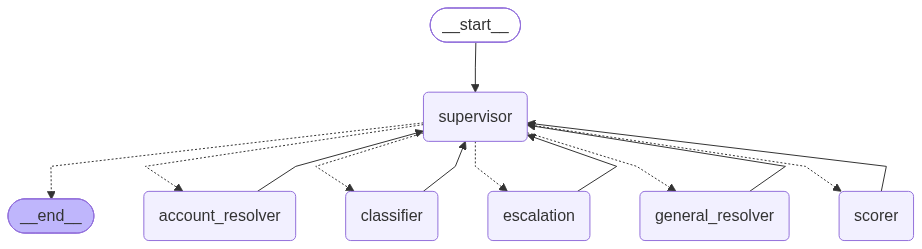

In [86]:
display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [87]:
from langgraph.checkpoint.memory import MemorySaver

orchestrator = workflow.compile(checkpointer=MemorySaver())

In [97]:
memory_test_ticket = {
    "status": "open",
    "date": datetime.now().isoformat(),
    "content": "I tried reserving a spot for an event but got an error, can you check what happened?",
    "user_id": cultpass_users[1]["id"],
    "owner_name": cultpass_users[1]["name"],
    "role": "user",
    "channel": "chat",
    "tags": "reservation, error, booking",
}
result = submit_ticket(memory_test_ticket)
print(result)

{'messages': [HumanMessage(content='I tried reserving a spot for an event but got an error, can you check what happened?', additional_kwargs={}, response_metadata={}, id='9d410fb6-c66a-4e76-9d0d-7cec74a69f32')], 'user_id': 'f556c0', 'ticket_status': 'resolved', 'ticket_data': {'status': 'open', 'date': '2026-09-05T13:22:19.598466', 'content': 'I tried reserving a spot for an event but got an error, can you check what happened?', 'user_id': 'f556c0', 'owner_name': 'Bob Stone', 'role': 'user', 'channel': 'chat', 'tags': 'reservation, error, booking'}, 'thread_id': '7a8c3b55-ac82-41ed-a05d-659f7b3c94ca', 'resolution_confidence_score': 0.9, 'account_evidence': {'get_account_profile': ["{'tier': 'basic', 'status': 'cancelled', 'monthly_quota': 8, 'started_at': datetime.datetime(2026, 9, 4, 10, 53, 9, 311606), 'ended_at': None, 'is_blocked': False}"], 'get_reservation_history': [[]]}, 'route': 'account', 'routing_reason': 'The user is experiencing an error while trying to reserve a spot for 

In [89]:
for ticket in tickets:
    result = submit_ticket(ticket)
    print(result)

{'messages': [HumanMessage(content='How do I reserve a spot for an experience on CultPass?', additional_kwargs={}, response_metadata={}, id='671f170a-9465-4ef4-a965-8a87a464de03')], 'user_id': 'f556c0', 'ticket_status': 'resolved', 'ticket_data': {'status': 'open', 'date': '2026-09-05T11:17:45.697092', 'content': 'How do I reserve a spot for an experience on CultPass?', 'user_id': 'f556c0', 'owner_name': 'Bob Stone', 'role': 'user', 'channel': 'chat', 'tags': 'reservation, events, booking'}, 'thread_id': '18be4025-68e9-4793-b124-7b896109c660', 'resolution_confidence_score': 0.8, 'retrieved_docs': ['How to Reserve a Spot for an Event'], 'route': 'general', 'routing_reason': 'The question is about how to reserve a spot, which is a general process applicable to all users.', 'decision_log': [{'agent': 'classifier', 'action': 'routed to general', 'result': 'Reason: The question is about how to reserve a spot, which is a general process applicable to all users., Confidence: 0.9'}, {'agent': 

In [84]:
from data.models.udahub import User as UdahubUser
from data.models.udahub import TicketMetadata, Ticket, TicketMessage

def persist_ticket(state: State, final_answer: str, final_status: str) -> None:
    """Save ticket resolution information for future reference"""
    udahub_db = "data/core/udahub.db"
    engine = create_engine(f"sqlite:///{udahub_db}", echo=False)
    with get_session(engine) as session:
        user = session.query(UdahubUser).filter_by(account_id="cultpass", external_user_id=state["user_id"]).first()
        if not user:
            user = UdahubUser(
                user_id=str(uuid.uuid4()),
                account_id="cultpass",
                external_user_id=state["user_id"],
                user_name=state["ticket_data"]["owner_name"],
            )
        
        ticket = Ticket(
            ticket_id=str(uuid.uuid4()),
            account_id="cultpass",
            user_id=user.user_id,
            channel=state["ticket_data"]["channel"],
        )
        metadata = TicketMetadata(
            ticket_id=ticket.ticket_id,
            status=final_status,
            main_issue_type=state["route"],
            tags=state["ticket_data"]["tags"],
        )
        first_message = TicketMessage(
            message_id=str(uuid.uuid4()),
            ticket_id=ticket.ticket_id,
            role=state["ticket_data"]["role"],
            content=state["ticket_data"]["content"],
        )
        ai_message = TicketMessage(
            message_id=str(uuid.uuid4()),
            ticket_id=ticket.ticket_id,
            role="ai",
            content=final_answer,
        )
        session.add_all([user, ticket, metadata, first_message, ai_message])


# Test Cases

In [41]:
cultpass_users = []

with open('data/external/cultpass_users.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        cultpass_users.append(json.loads(line))

cultpass_users

[{'id': 'a4ab87',
  'name': 'Alice Kingsley',
  'email': 'alice.kingsley@wonderland.com',
  'is_blocked': True},
 {'id': 'f556c0',
  'name': 'Bob Stone',
  'email': 'bob.stone@granite.com',
  'is_blocked': False},
 {'id': '88382b',
  'name': 'Cathy Bloom',
  'email': 'cathy.bloom@florals.org',
  'is_blocked': False},
 {'id': '888fb2',
  'name': 'David Noir',
  'email': 'david.noir@shadowmail.com',
  'is_blocked': True},
 {'id': 'f1f10d',
  'name': 'Eva Green',
  'email': 'eva.green@ecosoul.net',
  'is_blocked': False},
 {'id': 'e6376d',
  'name': 'Frank Ocean',
  'email': 'frank.ocean@seawaves.io',
  'is_blocked': False}]

In [42]:
from datetime import datetime

# Domain-accurate CultPass test tickets.
# cultpass_users indices assumed loaded from cultpass_users.jsonl, e.g.:
#   cultpass_users[0] -> Alice Kingsley (is_blocked=True)
#   cultpass_users[1] -> Bob Stone
#   cultpass_users[2] -> Cathy Bloom
#   cultpass_users[3] -> David Noir (is_blocked=True)
#   cultpass_users[4] -> Eva Green
#   cultpass_users[5] -> Frank Ocean

tickets = [
    # 1. GENERAL — should route to General Resolver, hit a real KB article
    # ("How to Reserve a Spot for an Event"), resolve with high confidence.
    {
        "status": "open",
        "date": datetime.now().isoformat(),
        "content": "How do I reserve a spot for an experience on CultPass?",
        "user_id": cultpass_users[1]["id"],
        "owner_name": cultpass_users[1]["name"],
        "role": "user",
        "channel": "chat",
        "tags": "reservation, events, booking",
    },

    # 2. ACCOUNT — should route to Account Resolver, needs a real DB lookup
    # against this specific user's blocked status (Alice is is_blocked=True).
    {
        "status": "open",
        "date": datetime.now().isoformat(),
        "content": "I keep getting blocked from logging in, can you check my account status?",
        "user_id": cultpass_users[0]["id"],
        "owner_name": cultpass_users[0]["name"],
        "role": "user",
        "channel": "chat",
        "tags": "login, access, account",
    },

    # 3. ACCOUNT — subscription-tier lookup specific to this user.
    {
        "status": "open",
        "date": datetime.now().isoformat(),
        "content": "What subscription tier am I currently on, and how many experiences do I have left this month?",
        "user_id": cultpass_users[2]["id"],
        "owner_name": cultpass_users[2]["name"],
        "role": "user",
        "channel": "chat",
        "tags": "subscription, quota, account",
    },

    # 4. AMBIGUOUS — vague enough to plausibly trigger low classification
    # confidence, exercising the "fallback to general" path.
    {
        "status": "open",
        "date": datetime.now().isoformat(),
        "content": "Something's wrong with my pass, can you help?",
        "user_id": cultpass_users[4]["id"],
        "owner_name": cultpass_users[4]["name"],
        "role": "user",
        "channel": "chat",
        "tags": "issue, pass",
    },

    # 5. ESCALATE — general in nature (no specific user data needed) but not
    # covered by any of the 19 KB articles, so General Resolver should come
    # back grounded=False, Scorer should score low, Escalation should trigger.
    {
        "status": "open",
        "date": datetime.now().isoformat(),
        "content": "Can I gift my unused monthly experiences to a friend who isn't a CultPass member?",
        "user_id": cultpass_users[5]["id"],
        "owner_name": cultpass_users[5]["name"],
        "role": "user",
        "channel": "chat",
        "tags": "gifting, experiences, sharing",
    },
]

# 6. REOPENED-TICKET scenario — run ticket #1 (or any resolved ticket) once
# via submit_ticket(tickets[0]), note the thread_id it generated, then call
# submit_ticket() again with a NEW message on the SAME thread_id to confirm
# Supervisor's reopened-ticket branch routes straight to Escalation.
followup_message = {
    "status": "open",
    "date": datetime.now().isoformat(),
    "content": "That didn't actually fix it, I'm still having the same problem.",
    "user_id": cultpass_users[1]["id"],
    "owner_name": cultpass_users[1]["name"],
    "role": "user",
    "channel": "chat",
    "tags": "follow-up",
}